<a href="https://colab.research.google.com/github/itsjustRohitch/CHINTA_SRI_DURGA_ROHIT-ML-LAB/blob/main/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Mall_Customers.csv'
df = pd.read_csv(file_path)


In [20]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [22]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [23]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [24]:
df = df.drop('CustomerID', axis=1)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


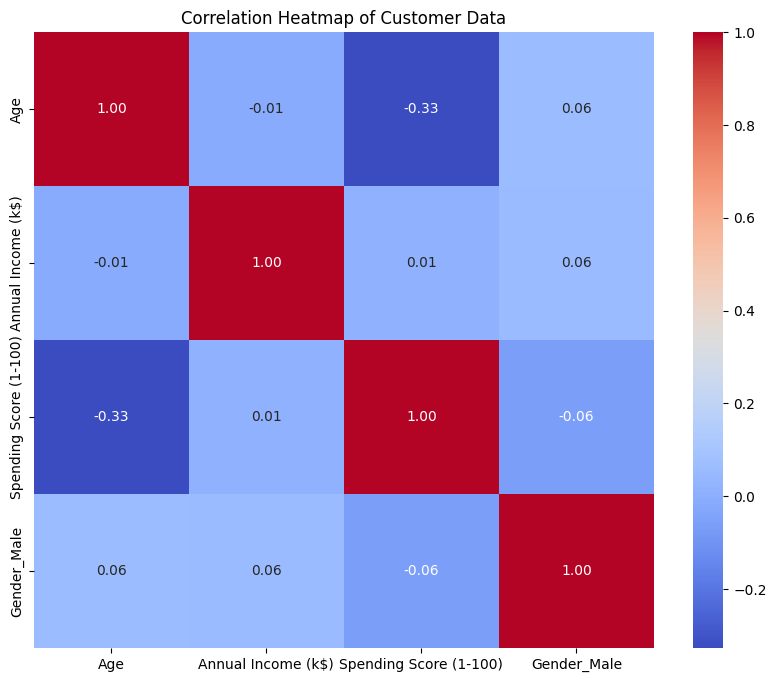

In [25]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Customer Data')
plt.show()

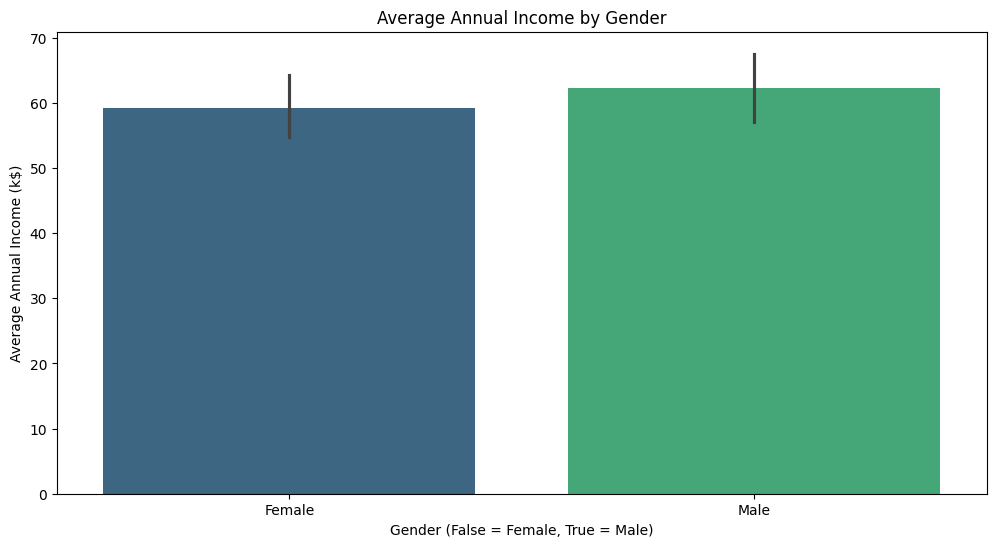

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Gender_Male', y='Annual Income (k$)', data=df, hue='Gender_Male', palette='viridis', legend=False)
plt.title('Average Annual Income by Gender')
plt.xlabel('Gender (False = Female, True = Male)')
plt.ylabel('Average Annual Income (k$)')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

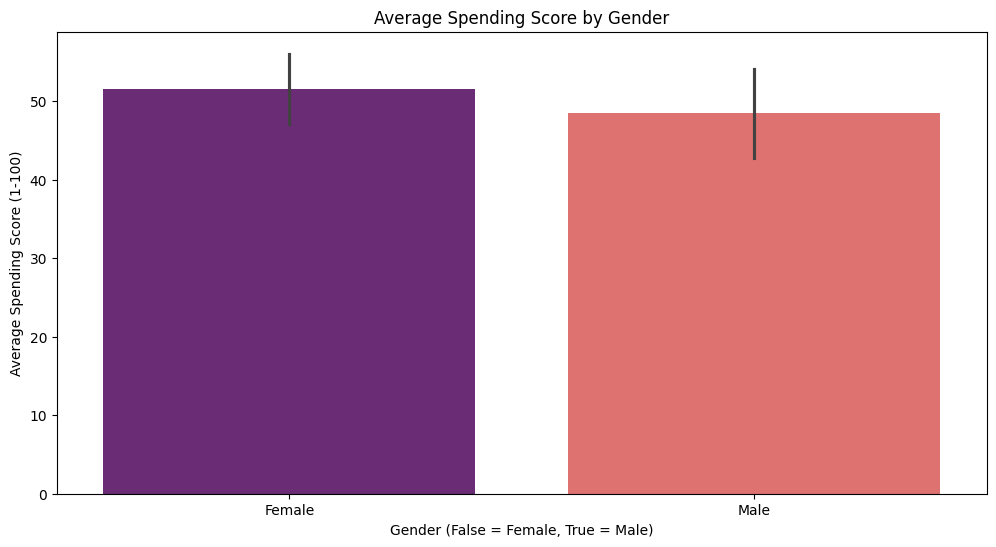

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Gender_Male', y='Spending Score (1-100)', data=df, hue='Gender_Male', palette='magma', legend=False)
plt.title('Average Spending Score by Gender')
plt.xlabel('Gender (False = Female, True = Male)')
plt.ylabel('Average Spending Score (1-100)')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

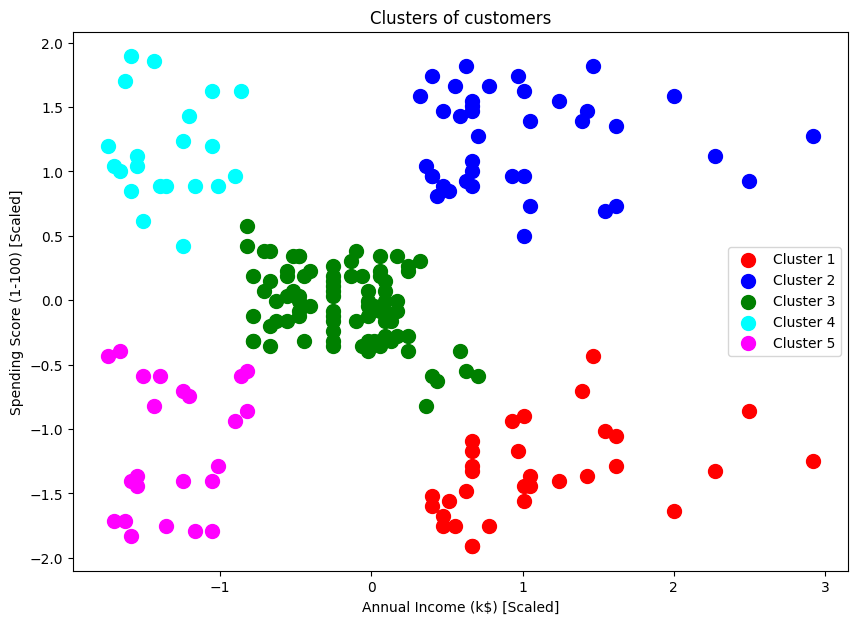

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,Cluster
0,19,15,39,True,4
1,21,15,81,True,3
2,20,16,6,False,4
3,23,16,77,False,3
4,31,17,40,False,4


In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

agg_clustering = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = agg_clustering.fit_predict(X_scaled)
df['Cluster'] = y_hc

plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[y_hc == 0, 0], X_scaled[y_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_hc == 1, 0], X_scaled[y_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_hc == 2, 0], X_scaled[y_hc == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X_scaled[y_hc == 3, 0], X_scaled[y_hc == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X_scaled[y_hc == 4, 0], X_scaled[y_hc == 4, 1], s=100, c='magenta', label='Cluster 5')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$) [Scaled]')
plt.ylabel('Spending Score (1-100) [Scaled]')
plt.legend()
plt.show()

display(df.head())

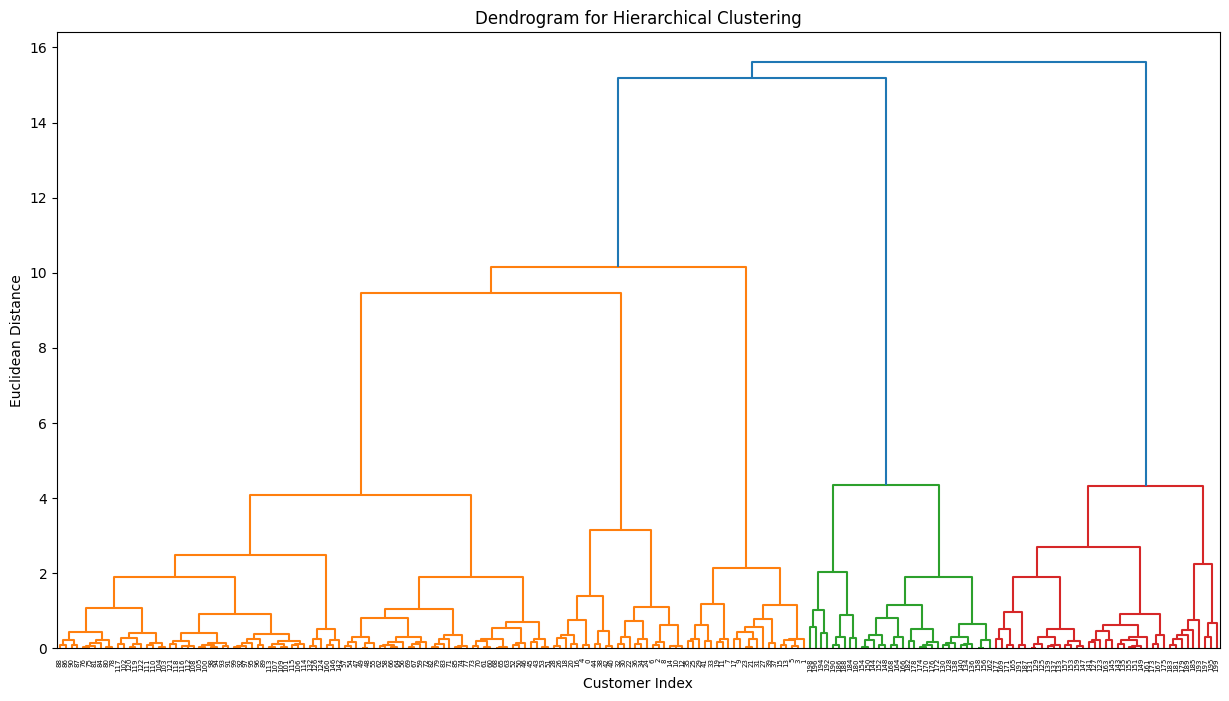

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate the linkage matrix
linked_data = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()

In [31]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(X_scaled, y_hc)

print(f"The Silhouette Score for the Agglomerative Clustering is: {silhouette_avg:.4f}")

The Silhouette Score for the Agglomerative Clustering is: 0.5538
